# Analyse Qualité de l'Air (AQI) — Notebook IA1

Ce notebook se connecte au data warehouse Neon (PostgreSQL) alimenté par le pipeline AQI,
explore les données, et produit les analyses/visualisations utilisées dans le dashboard Power BI.

**Villes suivies** : Paris, Antananarivo, New Delhi, Beijing, Los Angeles

**Source des données** : OpenWeather Air Pollution API, collectées automatiquement via GitHub Actions
(collecte horaire + backfill), chargées dans un schéma en étoile (`fact_air_quality`, `dim_city`, `dim_time`).

## 1. Installation et imports

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv



load_dotenv(dotenv_path=r"C:\dev\Donne-2-aqi\aqi-pipeline\.env")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Connexion au Data Warehouse (Neon)

La chaîne de connexion est lue depuis un fichier `.env` local .


In [2]:
load_dotenv()
DATABASE_URL = os.getenv("DATABASE_URL")

assert DATABASE_URL, "DATABASE_URL manquante : vérifie ton .env ou l'option B ci-dessus."

engine = create_engine(DATABASE_URL)
print("Connexion configurée avec succès.")

Connexion configurée avec succès.


## 3. Chargement des données du warehouse

In [3]:
query = """
SELECT
    f.aqi, f.co, f.no, f.no2, f.o3, f.so2, f.pm2_5, f.pm10, f.nh3,
    c.city_name, c.country, c.latitude, c.longitude,
    t.full_datetime, t.date, t.hour, t.day_of_week, t.is_weekend, t.month, t.year
FROM fact_air_quality f
JOIN dim_city c ON f.city_id = c.city_id
JOIN dim_time t ON f.time_id = t.time_id
ORDER BY c.city_name, t.full_datetime;
"""

df = pd.read_sql(query, engine)
print(f"{len(df)} lignes chargées.")
df.head()

10567 lignes chargées.


,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3,city_name,country,latitude,longitude,full_datetime,date,hour,day_of_week,is_weekend,month,year
0,1,66.98,0.03,0.11,46.27,0.11,0.60,1.55,0.27,Antananarivo,Madagascar,-18.8792,47.5079,2026-04-26 07:00:00+00:00,2026-04-26,7,Sunday,True,4,2026
1,1,62.14,0.02,0.07,47.18,0.10,0.51,1.22,0.24,Antananarivo,Madagascar,-18.8792,47.5079,2026-04-26 08:00:00+00:00,2026-04-26,8,Sunday,True,4,2026
2,1,61.16,0.02,0.06,45.55,0.10,0.55,1.26,0.24,Antananarivo,Madagascar,-18.8792,47.5079,2026-04-26 09:00:00+00:00,2026-04-26,9,Sunday,True,4,2026
3,1,61.43,0.02,0.07,44.97,0.11,0.65,1.31,0.27,Antananarivo,Madagascar,-18.8792,47.5079,2026-04-26 10:00:00+00:00,2026-04-26,10,Sunday,True,4,2026
4,1,62.03,0.02,0.08,44.14,0.11,0.78,1.45,0.33,Antananarivo,Madagascar,-18.8792,47.5079,2026-04-26 11:00:00+00:00,2026-04-26,11,Sunday,True,4,2026


## 4. Exploration rapide des données

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10567 entries, 0 to 10566
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   aqi            10567 non-null  int64              
 1   co             10567 non-null  float64            
 2   no             10567 non-null  float64            
 3   no2            10567 non-null  float64            
 4   o3             10567 non-null  float64            
 5   so2            10567 non-null  float64            
 6   pm2_5          10567 non-null  float64            
 7   pm10           10567 non-null  float64            
 8   nh3            10567 non-null  float64            
 9   city_name      10567 non-null  str                
 10  country        10567 non-null  str                
 11  latitude       10567 non-null  float64            
 12  longitude      10567 non-null  float64            
 13  full_datetime  10567 non-null  datetime64[us, UTC]
 14  d

In [5]:
# Période couverte et nombre de lignes par ville
resume = df.groupby("city_name").agg(
    premiere_mesure=("full_datetime", "min"),
    derniere_mesure=("full_datetime", "max"),
    nb_lignes=("full_datetime", "count"),
)
resume

,premiere_mesure,derniere_mesure,nb_lignes
city_name,,,
Antananarivo,2026-04-26 07:00:00+00:00,2026-07-28 10:52:02+00:00,2129
Beijing,2026-04-26 07:00:00+00:00,2026-07-28 10:52:02+00:00,2104
Los Angeles,2026-04-26 07:00:00+00:00,2026-07-28 10:52:02+00:00,2127
New Delhi,2026-04-26 07:00:00+00:00,2026-07-28 10:52:02+00:00,2080
Paris,2026-04-26 07:00:00+00:00,2026-07-28 10:52:02+00:00,2127


In [6]:
# Vérification des valeurs manquantes
df.isna().sum()

aqi              0
co               0
no               0
no2              0
o3               0
so2              0
pm2_5            0
pm10             0
nh3              0
city_name        0
country          0
latitude         0
longitude        0
full_datetime    0
date             0
hour             0
day_of_week      0
is_weekend       0
month            0
year             0
dtype: int64

## 5. AQI moyen par ville

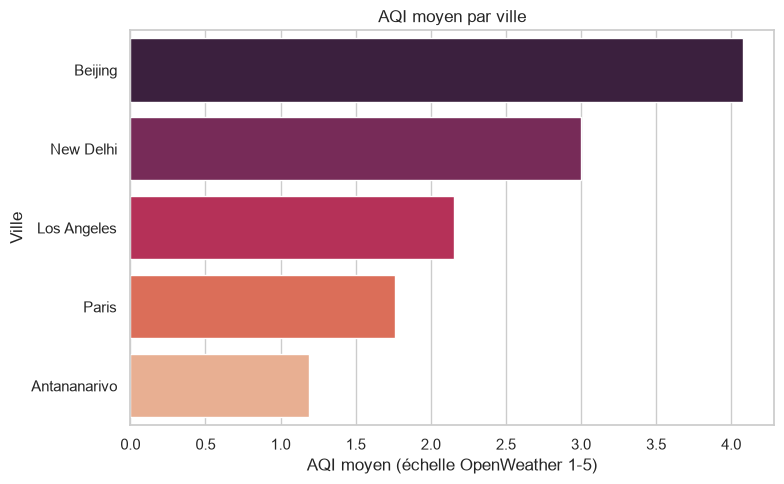

city_name
Beijing         4.080798
New Delhi       2.997596
Los Angeles     2.151387
Paris           1.758815
Antananarivo    1.191639
Name: aqi, dtype: float64

In [7]:
aqi_moyen = df.groupby("city_name")["aqi"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=aqi_moyen.values, y=aqi_moyen.index, hue=aqi_moyen.index, palette="rocket", legend=False)
plt.xlabel("AQI moyen (échelle OpenWeather 1-5)")
plt.ylabel("Ville")
plt.title("AQI moyen par ville")
plt.tight_layout()
plt.show()

aqi_moyen

## 6. Évolution de l'AQI dans le temps, par ville

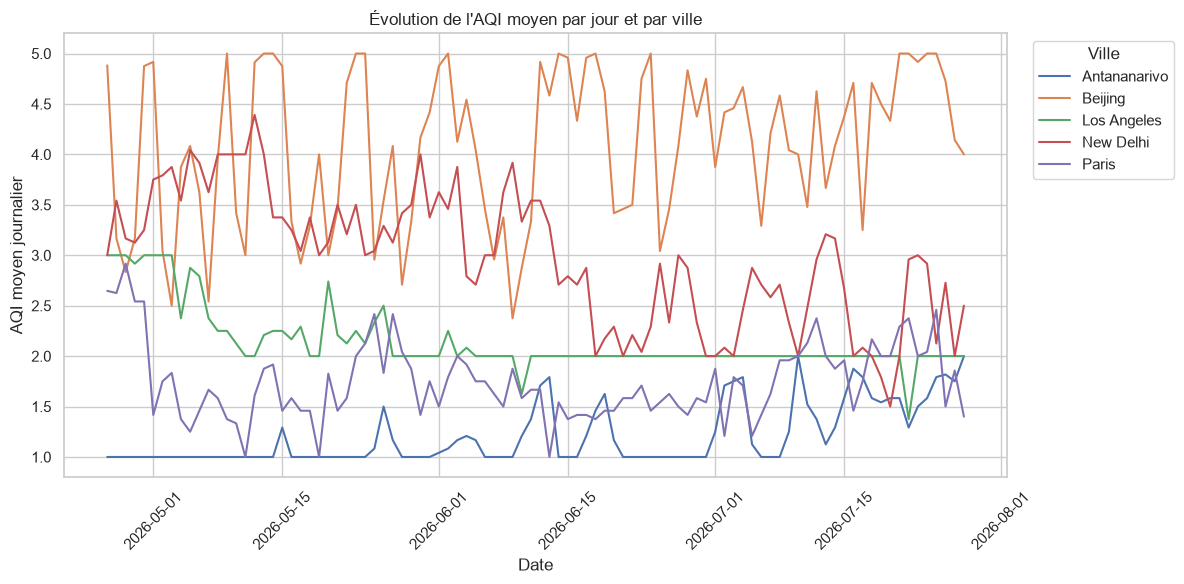

In [8]:
evolution = df.groupby(["date", "city_name"])["aqi"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=evolution, x="date", y="aqi", hue="city_name")
plt.xlabel("Date")
plt.ylabel("AQI moyen journalier")
plt.title("Évolution de l'AQI moyen par jour et par ville")
plt.xticks(rotation=45)
plt.legend(title="Ville", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 7. Polluant dominant par ville (PM2.5)

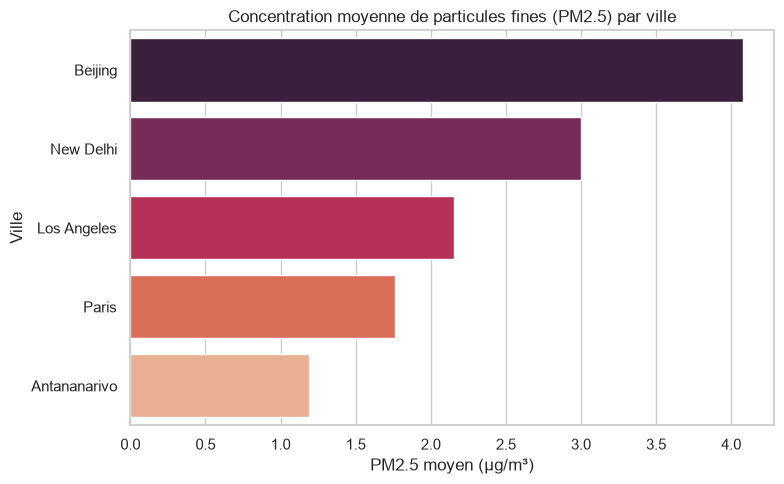

In [9]:
pm25_moyen = df.groupby("city_name")["pm2_5"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=aqi_moyen.values, y=aqi_moyen.index, hue=aqi_moyen.index, palette="rocket", legend=False)
plt.xlabel("PM2.5 moyen (µg/m³)")
plt.ylabel("Ville")
plt.title("Concentration moyenne de particules fines (PM2.5) par ville")
plt.tight_layout()
plt.show()

## 8. Semaine vs Weekend

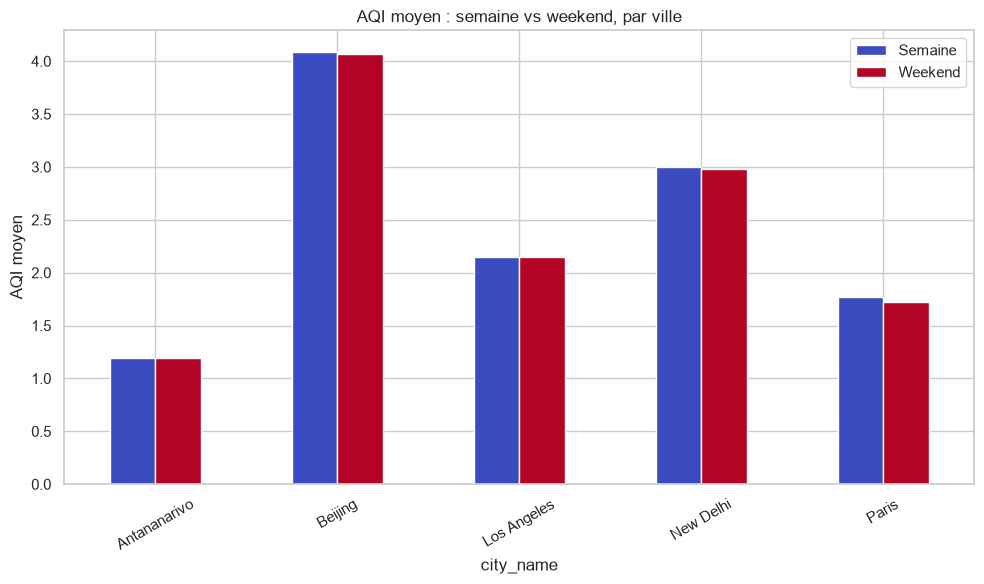

,Semaine,Weekend
city_name,,
Antananarivo,1.191079,1.192982
Beijing,4.086000,4.067881
Los Angeles,2.151899,2.150160
New Delhi,3.003388,2.983444
Paris,1.773484,1.723642


In [10]:
weekend_comparaison = df.groupby(["city_name", "is_weekend"])["aqi"].mean().unstack()
weekend_comparaison.columns = ["Semaine", "Weekend"]

weekend_comparaison.plot(kind="bar", figsize=(10, 6), colormap="coolwarm")
plt.ylabel("AQI moyen")
plt.title("AQI moyen : semaine vs weekend, par ville")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

weekend_comparaison

## 9. Corrélation entre polluants

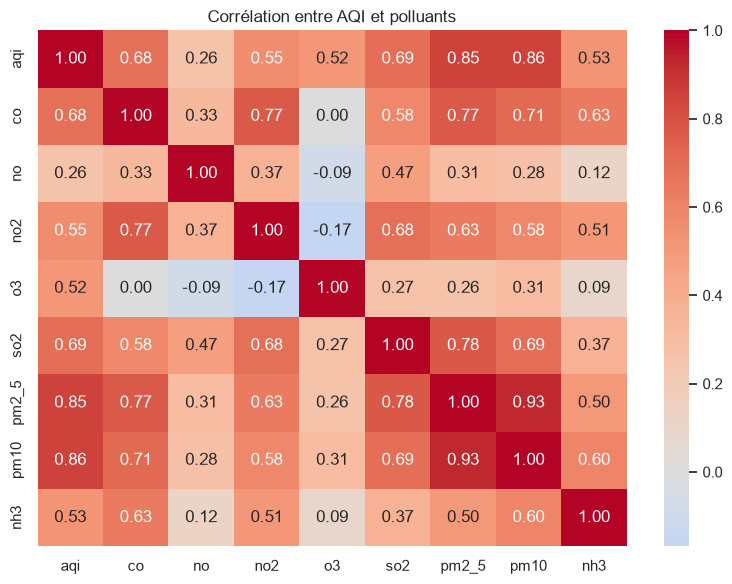

In [11]:
polluants = ["aqi", "co", "no", "no2", "o3", "so2", "pm2_5", "pm10", "nh3"]
correlation = df[polluants].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Corrélation entre AQI et polluants")
plt.tight_layout()
plt.show()

## 10. Synthèse des insights

- **Ville la plus polluée en moyenne** : `beijin 4.07`
- **Tendance temporelle observée** : `pic de pollution certains jours, stabilité globale.`
- **Polluant dominant** : `PM2.5 nettement plus élevé à New Delhi et Beijing`
- **Effet weekend/semaine** : `AQI légèrement plus bas le weekend dans les grandes métropoles, cohérent avec moins de trafic routier`
- **Polluants corrélés** : `NO2 et CO fortement corrélés, cohérent avec une origine commune (trafic automobile)`

Ces insights alimentent directement les visuels du dashboard Power BI (carte, courbes, classement des villes).